# 1. Installing Dependecies and Dataset Download


In [ ]:
!pip install langdetect datasets

from langdetect import detect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 45.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.2 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=21c6b65abd856e1f566e586c71adae81966c6572df96588b3aff4cd594d0eca5
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's depe

In [ ]:
import pandas as pd
import kagglehub
from sklearn.utils import resample
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

path = kagglehub.dataset_download("atifaliak/youtube-comments-dataset")


# Load the dataset
df = pd.read_csv(path + '/YoutubeCommentsDataSet.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (18408, 2)


,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


#2. Data Cleaning and Preprocessing


In [ ]:
# 2.1 Remove NaN values
print("Before dropping NaNs", df.shape)
df.dropna(inplace=True)
print("After dropping NaNs", df.shape)



# 2.2 Filter out non-English comments using langdetect

def is_english_comment(text):
    try:
        return detect(text) == 'en'
    except:
        return False

# Apply language filter
df['is_english'] = df['Comment'].apply(is_english_comment)
df = df[df['is_english']]
df = df.drop(columns=['is_english'])
print("After filtering non-English:", df.shape)

# 2.3 Remove stop words
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Define a simple function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    words_filtered = [w for w in words if w.lower() not in stop_words]
    return ' '.join(words_filtered)

# Apply stop word removal
df['Comment'] = df['Comment'].apply(remove_stopwords)

# 2.4 Retain only desired sentiment labels
df = df[df['Sentiment'].isin(['positive', 'negative', 'neutral'])]
print("After retaining only pos/neg/neutral:", df.shape)

# Quick check of class distribution
print(df['Sentiment'].value_counts())


Before dropping NaNs (31941, 2)
After dropping NaNs (31941, 2)
After filtering non-English: (29238, 2)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


After retaining only pos/neg/neutral: (29238, 2)
Sentiment
negative    9850
positive    9801
neutral     9587
Name: count, dtype: int64


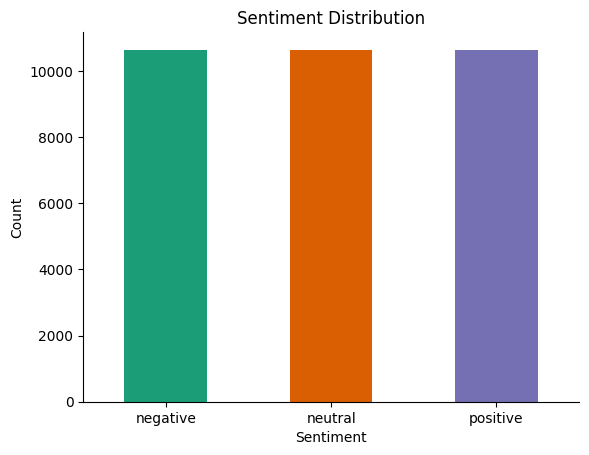

In [ ]:
# Separate by class
df_positive = df[df['Sentiment'] == 'positive']
df_neutral = df[df['Sentiment'] == 'neutral']
df_negative = df[df['Sentiment'] == 'negative']

# Find the largest class size
max_size = max(len(df_positive), len(df_neutral), len(df_negative))

# Upsample all classes to the size of the largest
df_positive_balanced = resample(df_positive, replace=True, n_samples=max_size, random_state=42)
df_neutral_balanced = resample(df_neutral, replace=True, n_samples=max_size, random_state=42)
df_negative_balanced = resample(df_negative, replace=True, n_samples=max_size, random_state=42)

# Combine into one balanced dataset
df_balanced = pd.concat([df_positive_balanced, df_neutral_balanced, df_negative_balanced])

# Shuffle the rows
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Count of each sentiment
sentiment_counts = df['Sentiment'].value_counts()


df.groupby('Sentiment').size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.xticks(rotation=0)
plt.show()


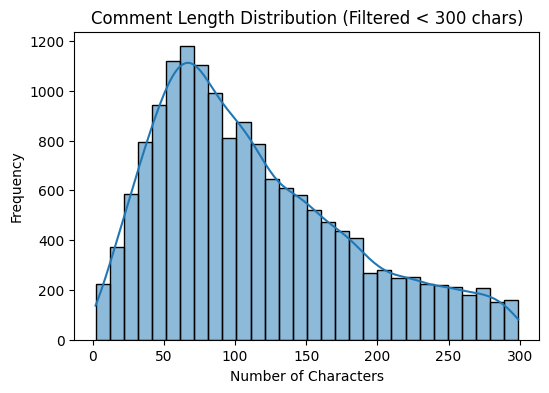

In [ ]:
df['comment_length'] = df['Comment'].str.len()
plt.figure(figsize=(6, 4))
sns.histplot(df[df['comment_length'] < 300]['comment_length'], bins=30, kde=True)
plt.title("Comment Length Distribution (Filtered < 300 chars)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


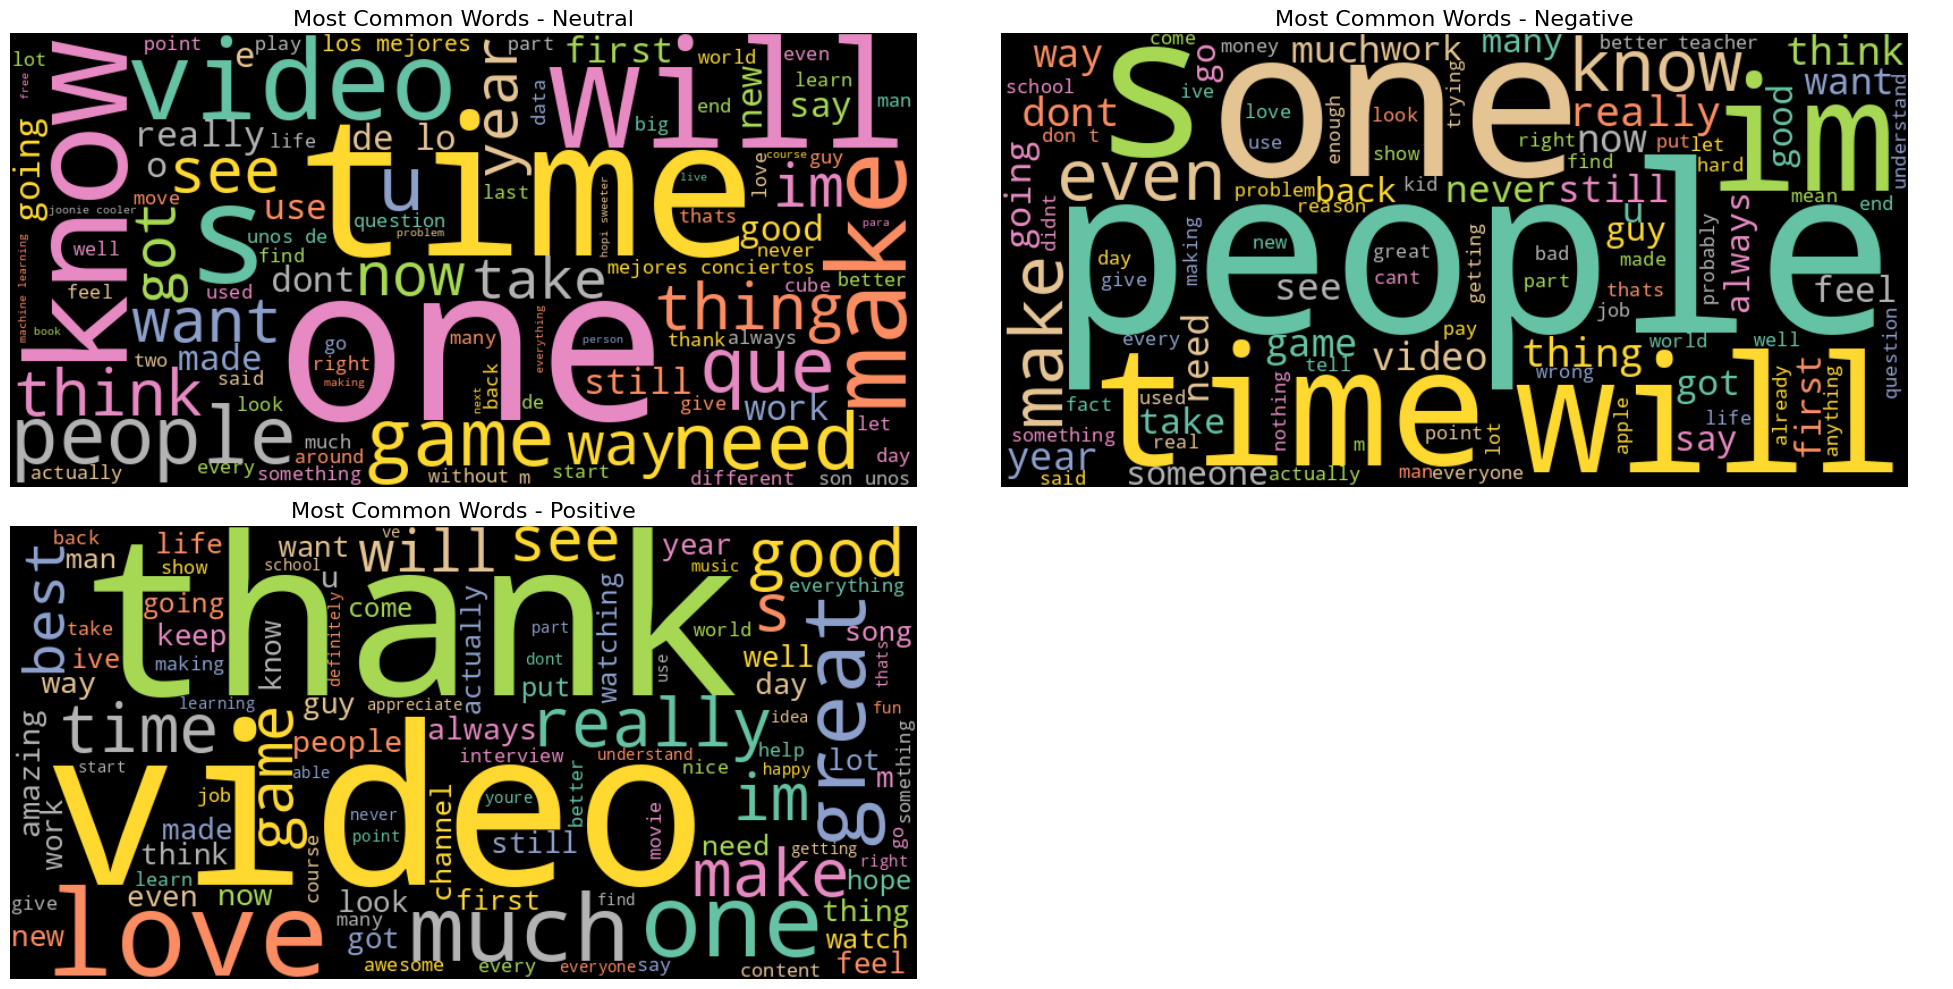

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

config = {
    'width': 800,
    'height': 400,
    'background_color': 'black',
    'colormap': 'Set2',
    'max_words': 100
}

sentiments = df['Sentiment'].unique()
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for i, sentiment in enumerate(sentiments):
    text = " ".join(df[df['Sentiment'] == sentiment]['Comment'].dropna().astype(str))
    wc = WordCloud(**config).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Most Common Words - {sentiment.capitalize()}", fontsize=16, color='black')
    axes[i].axis('off')

axes[3].axis('off')

plt.tight_layout()
plt.show()


#3. Model Preparation


In [ ]:
# Split dataset into train and test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Sentiment'])
print(f"Train size: {train_df.shape[0]}, Test size: {test_df.shape[0]}")

# Prepare label encoding
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}
train_texts = list(train_df['Comment'])
train_labels = [label2id[label] for label in train_df['Sentiment']]
test_texts = list(test_df['Comment'])
test_labels = [label2id[label] for label in test_df['Sentiment']]

# Show a sample
print(train_texts[0], "->", train_df['Sentiment'].iloc[0])


Train size: 13009, Test size: 3253
sir want say thank help us gain knowledge encourage us start data science journey -> positive


#Model Initialization


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Function to load model and tokenizer
def load_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    # If the model's classifier is pre-trained on a different number of labels, we reinitialize it
    model.config.id2label = id2label
    model.config.label2id = label2id
    return tokenizer, model

# Example: load BERT
bert_tokenizer, bert_model = load_model_and_tokenizer('bert-base-uncased')
print("BERT model and tokenizer loaded.")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model and tokenizer loaded.


#Baseline Evaluation (Before Fine-Tuning)


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import torch
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def evaluate_model(tokenizer, model, test_texts, test_labels, batch_size=16):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    preds = []

    test_texts = [str(text) for text in test_texts]

    for i in tqdm(range(0, len(test_texts), batch_size), desc="Evaluating"):
        batch_texts = test_texts[i:i+batch_size]
        enc = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            output = model(**enc)
            logits = output.logits
            batch_preds = logits.argmax(dim=1).cpu().numpy()
            preds.extend(batch_preds)

        del enc, output, logits
        torch.cuda.empty_cache()

    precision, recall, f1, _ = precision_recall_fscore_support(test_labels, preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(test_labels, preds)
    return precision, recall, f1, accuracy


In [ ]:
model_names = {
    'BERT': 'bert-base-uncased',
    'RoBERTa': 'roberta-base',
    'DistilBERT': 'distilbert-base-uncased',
    'DeBERTa': 'microsoft/deberta-base'
}

print("Preloading tokenizers...")
tokenizers = {}
for name, ckpt in model_names.items():
    tokenizers[name] = AutoTokenizer.from_pretrained(ckpt)

# Evaluate all models
baseline_metrics = {}
for name, ckpt in model_names.items():
    print(f"\nEvaluating {name} before fine-tuning...")

    model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=3)

    # Evaluate
    precision, recall, f1, accuracy = evaluate_model(tokenizers[name], model, test_texts, test_labels, batch_size=8)

    # Free memory
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    baseline_metrics[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

    print(f"{name} - Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

baseline_metrics


Preloading tokenizers...

Evaluating BERT before fine-tuning...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating:   0%|          | 0/407 [00:00<?, ?it/s]

BERT - Accuracy: 0.31, Precision: 0.43, Recall: 0.31, F1: 0.29

Evaluating RoBERTa before fine-tuning...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

DistilBERT - Accuracy: 0.27, Precision: 0.52, Recall: 0.27, F1: 0.29

Evaluating DeBERTa before fine-tuning...


Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating:   0%|          | 0/407 [00:00<?, ?it/s]

DeBERTa - Accuracy: 0.65, Precision: 0.43, Recall: 0.65, F1: 0.52


{'BERT': {'Accuracy': 0.3061789117737473,
  'Precision': 0.42955769070709227,
  'Recall': 0.3061789117737473,
  'F1-score': 0.2904379379113243},
 'RoBERTa': {'Accuracy': 0.6547802028896403,
  'Precision': 0.4287371140961986,
  'Recall': 0.6547802028896403,
  'F1-score': 0.5181801345550562},
 'DistilBERT': {'Accuracy': 0.26744543498309253,
  'Precision': 0.5227203368509663,
  'Recall': 0.26744543498309253,
  'F1-score': 0.29071349639133226},
 'DeBERTa': {'Accuracy': 0.6544727943436828,
  'Precision': 0.4287994623045353,
  'Recall': 0.6544727943436828,
  'F1-score': 0.5181293632975449}}

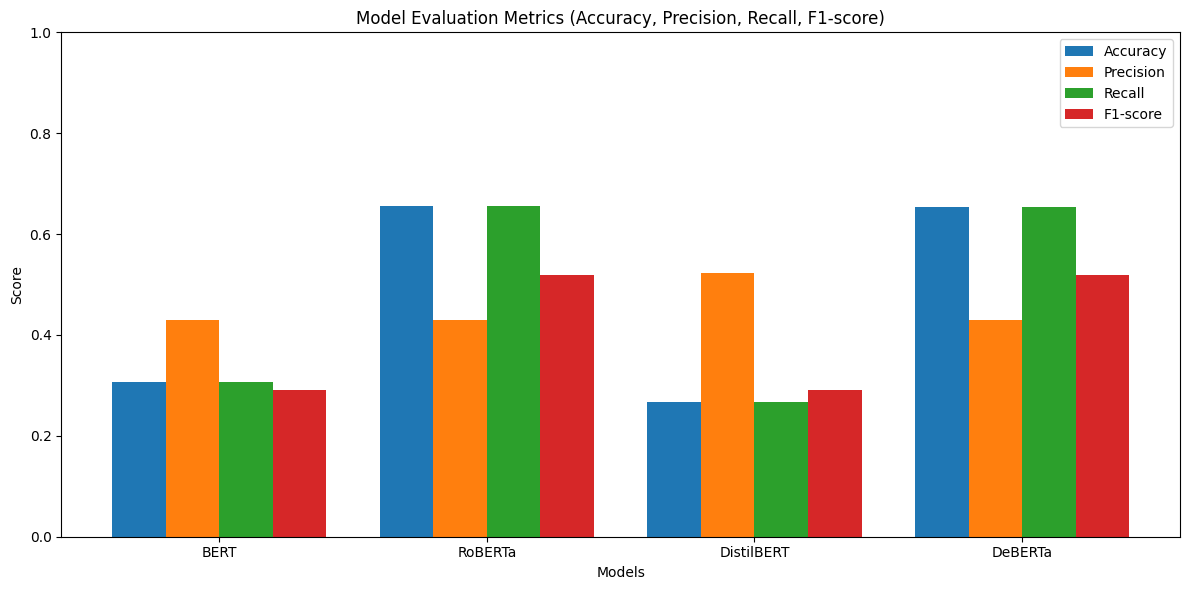

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data including Accuracy
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
models = list(baseline_metrics.keys())
data = [[baseline_metrics[model][metric] for model in models] for metric in metrics]

x = np.arange(len(models))
width = 0.2

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, data[i], width, label=metric)

# Customize plot
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Evaluation Metrics (Accuracy, Precision, Recall, F1-score)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.legend()
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


#4. Fine-Tuning the Models


In [ ]:
from torch.utils.data import Dataset

class CommentsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Optional: store metrics
fine_tuned_metrics = {}

def fine_tune_model(model_name, checkpoint, max_length=128):
    print(f"Fine‑tuning {model_name} using checkpoint: {checkpoint}...\n")

    # 1) Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=3)

    # 2) Build HF Datasets from your globals
    global train_texts, train_labels, test_texts, test_labels
    train_dataset = Dataset.from_dict({
        "text":   [str(t) for t in train_texts],
        "labels": train_labels
    })
    test_dataset = Dataset.from_dict({
        "text":   [str(t) for t in test_texts],
        "labels": test_labels
    })

    # 3) Tokenize with fixed max_length to avoid variable‑length tapes
    def tokenize_fn(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    train_dataset = train_dataset.map(tokenize_fn, batched=True)
    test_dataset  = test_dataset.map(tokenize_fn, batched=True)

    train_dataset.set_format("torch", columns=["input_ids","attention_mask","labels"])
    test_dataset .set_format("torch", columns=["input_ids","attention_mask","labels"])

    # 4) Define metrics
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc   = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(
            labels, preds, labels=[0,1,2], zero_division=0
        )
        return {
            "accuracy":       acc,
            "neg_precision": p[0], "neu_precision": p[1], "pos_precision": p[2],
            "neg_recall":    r[0], "neu_recall":    r[1], "pos_recall":    r[2],
            "neg_f1":        f1[0], "neu_f1":        f1[1], "pos_f1":        f1[2],
        }

    # 5) Training arguments (legacy flags)
    training_args = TrainingArguments(
        output_dir="./results",
        do_train=True,
        do_eval=True,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=1e-5,
        num_train_epochs=3,
        logging_steps=50,
        save_steps=500,
        save_total_limit=2,
    )

    # 6) Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
    )

    # 7) Train & Eval
    trainer.train()
    trainer.evaluate()

    # 8) Full preds for report + CM
    preds_output = trainer.predict(test_dataset)
    preds = np.argmax(preds_output.predictions, axis=-1)
    labels = preds_output.label_ids

    print("\n" + classification_report(
        labels,
        preds,
        target_names=["negative","neutral","positive"],
        digits=4
    ))

    # 9) Confusion matrix
    cm = confusion_matrix(labels, preds, labels=[0,1,2])
    names = ["negative","neutral","positive"]

    plt.figure(figsize=(6,5))
    im = plt.imshow(cm, aspect="auto")
    plt.xticks(np.arange(len(names)), names)
    plt.yticks(np.arange(len(names)), names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"{model_name} Confusion Matrix")
    for i in range(len(names)):
        for j in range(len(names)):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    # 10) Optionally store
    fine_tuned_metrics[model_name] = {
        "confusion_matrix": cm.tolist()
    }

    return model




Fine‑tuning BERT using checkpoint: bert-base-uncased...



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13009 [00:00<?, ? examples/s]

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: anotherperson786786 (anotherperson786786-e-tv-s-lor-nd-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.929100
100,0.773700
150,0.633400
200,0.621500
250,0.625200
300,0.681500
350,0.525900
400,0.559100
450,0.541600
500,0.604000



              precision    recall  f1-score   support

    negative     0.7563    0.6558    0.7025       459
     neutral     0.6832    0.6431    0.6625       664
    positive     0.8982    0.9404    0.9188      2130

    accuracy                         0.8395      3253
   macro avg     0.7792    0.7464    0.7613      3253
weighted avg     0.8343    0.8395    0.8360      3253



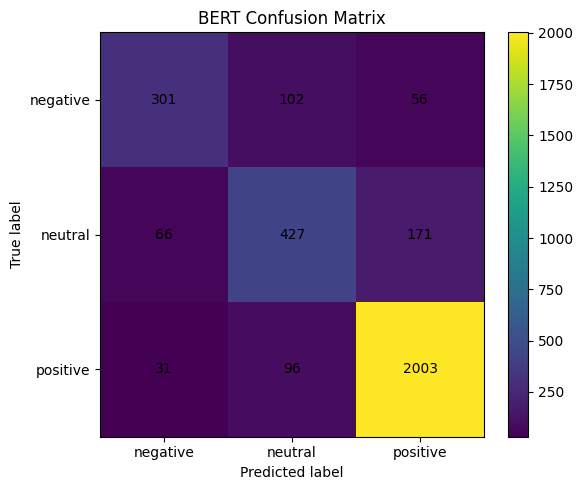

In [ ]:
bert_model = fine_tune_model('BERT', 'bert-base-uncased')


Fine‑tuning RoBERTa using checkpoint: roberta-base...



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13009 [00:00<?, ? examples/s]

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

Step,Training Loss
50,0.965400
100,0.782300
150,0.615600
200,0.641900
250,0.669200
300,0.615300
350,0.505200
400,0.591800
450,0.584000
500,0.592000



              precision    recall  f1-score   support

    negative     0.7401    0.6950    0.7169       459
     neutral     0.7030    0.6310    0.6651       664
    positive     0.9003    0.9408    0.9201      2130

    accuracy                         0.8429      3253
   macro avg     0.7811    0.7556    0.7673      3253
weighted avg     0.8374    0.8429    0.8394      3253



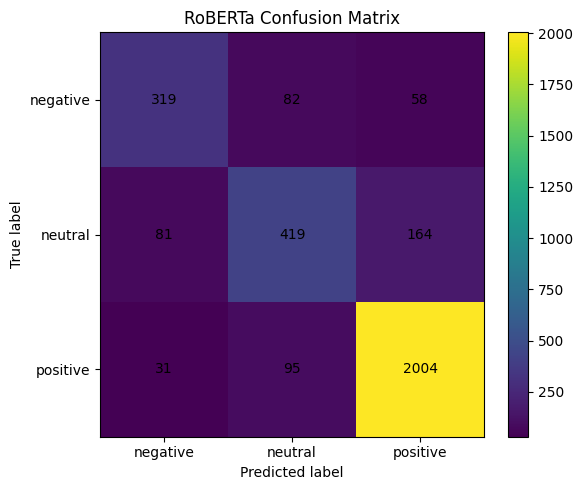

In [ ]:
roberta_model = fine_tune_model('RoBERTa', 'roberta-base')

Fine‑tuning DistilBERT using checkpoint: distilbert-base-uncased...



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13009 [00:00<?, ? examples/s]

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

Step,Training Loss
50,0.976600
100,0.830400
150,0.669200
200,0.642400
250,0.631100
300,0.607200
350,0.516800
400,0.549500
450,0.502400
500,0.572800



              precision    recall  f1-score   support

    negative     0.7351    0.6471    0.6883       459
     neutral     0.6635    0.6325    0.6476       664
    positive     0.8926    0.9286    0.9103      2130

    accuracy                         0.8285      3253
   macro avg     0.7638    0.7361    0.7487      3253
weighted avg     0.8236    0.8285    0.8253      3253



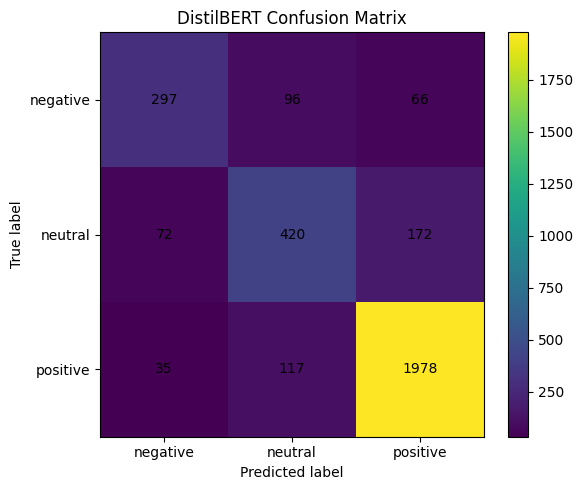

In [ ]:
distilbert_model = fine_tune_model('DistilBERT', 'distilbert-base-uncased')

Fine‑tuning DeBERTa using checkpoint: microsoft/deberta-base...



Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13009 [00:00<?, ? examples/s]

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

Step,Training Loss
50,1.042000
100,0.890100
150,0.719600
200,0.673800
250,0.639100
300,0.711200
350,0.556300
400,0.562300
450,0.539600
500,0.577200



              precision    recall  f1-score   support

    negative     0.7694    0.7124    0.7398       459
     neutral     0.6954    0.6325    0.6625       664
    positive     0.9002    0.9399    0.9196      2130

    accuracy                         0.8451      3253
   macro avg     0.7883    0.7616    0.7740      3253
weighted avg     0.8399    0.8451    0.8418      3253



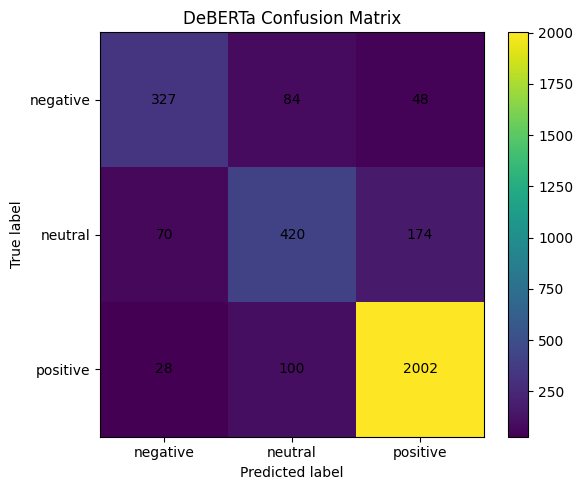

In [ ]:
deberta_model = fine_tune_model("DeBERTa", "microsoft/deberta-base", max_length=128)

#5. Results and Visualization


In [ ]:
models_list = {
    'BERT': 'bert-base-uncased',
    'RoBERTa': 'roberta-base',
    'DistilBERT': 'distilbert-base-uncased',
    'DeBERTa': 'microsoft/deberta-base'
}
print("models_list:", models_list)
print("fine_tuned_metrics keys:", fine_tuned_metrics.items())

models_list: {'BERT': 'bert-base-uncased', 'RoBERTa': 'roberta-base', 'DistilBERT': 'distilbert-base-uncased', 'DeBERTa': 'microsoft/deberta-base'}
fine_tuned_metrics keys: dict_items([('BERT', {'confusion_matrix': [[301, 102, 56], [66, 427, 171], [31, 96, 2003]]}), ('DistilBERT', {'confusion_matrix': [[297, 96, 66], [72, 420, 172], [35, 117, 1978]]}), ('DeBERTa', {'confusion_matrix': [[327, 84, 48], [70, 420, 174], [28, 100, 2002]]}), ('RoBERTa', {'confusion_matrix': [[319, 82, 58], [81, 419, 164], [31, 95, 2004]]})])


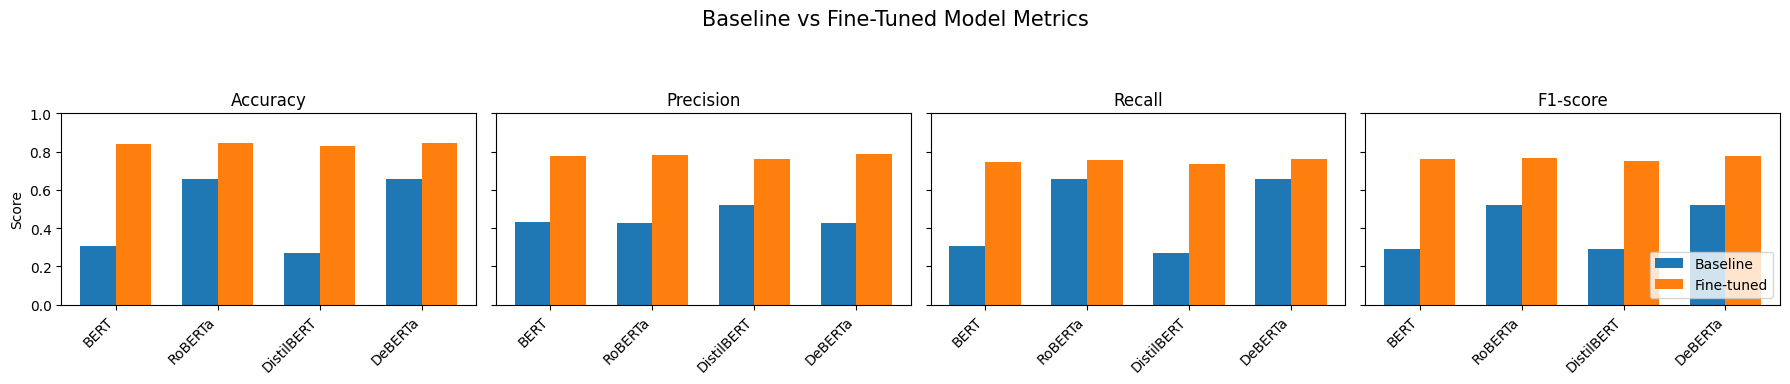

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# ── helper: compute macro-metrics from a confusion matrix ────────────
def cm2macro(cm):
    cm = np.asarray(cm)
    tp = np.diag(cm); fp = cm.sum(0) - tp; fn = cm.sum(1) - tp
    prec = np.divide(tp, tp + fp, where=(tp + fp) != 0)
    rec  = np.divide(tp, tp + fn, where=(tp + fn) != 0)
    macro_p, macro_r = prec.mean(), rec.mean()
    macro_f1 = 2 * macro_p * macro_r / (macro_p + macro_r + 1e-12)
    acc = tp.sum() / cm.sum()
    return acc, macro_p, macro_r, macro_f1

def enrich(dct):
    for m, v in dct.items():
        if "Accuracy" in v:
            continue                    # nothing to do
        a, p, r, f = cm2macro(v["confusion_matrix"])
        v.update({"Accuracy": a, "Precision": p, "Recall": r, "F1-score": f})
    return dct

# enrich the two dictionaries (adds the four metrics once)
enrich(baseline_metrics)
enrich(fine_tuned_metrics)

# ── plotting: grouped bars + improvement bars ───────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
models  = list(baseline_metrics.keys())
x = np.arange(len(models)); w = 0.35

# 1│ grouped bars (baseline vs fine-tuned)
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle("Baseline vs Fine-Tuned Model Metrics", fontsize=15)
for i, metric in enumerate(metrics):
    base_vals = [baseline_metrics[m][metric]   for m in models]
    fine_vals = [fine_tuned_metrics[m][metric] for m in models]
    ax = axes[i]
    ax.bar(x - w/2, base_vals, width=w, label="Baseline")
    ax.bar(x + w/2, fine_vals, width=w, label="Fine-tuned")
    ax.set_title(metric); ax.set_ylim(0, 1)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=45, ha="right")
    if i == 0: ax.set_ylabel("Score")
    if i == len(metrics)-1: ax.legend(loc="lower right")
plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()



#  Improvement Heatmap


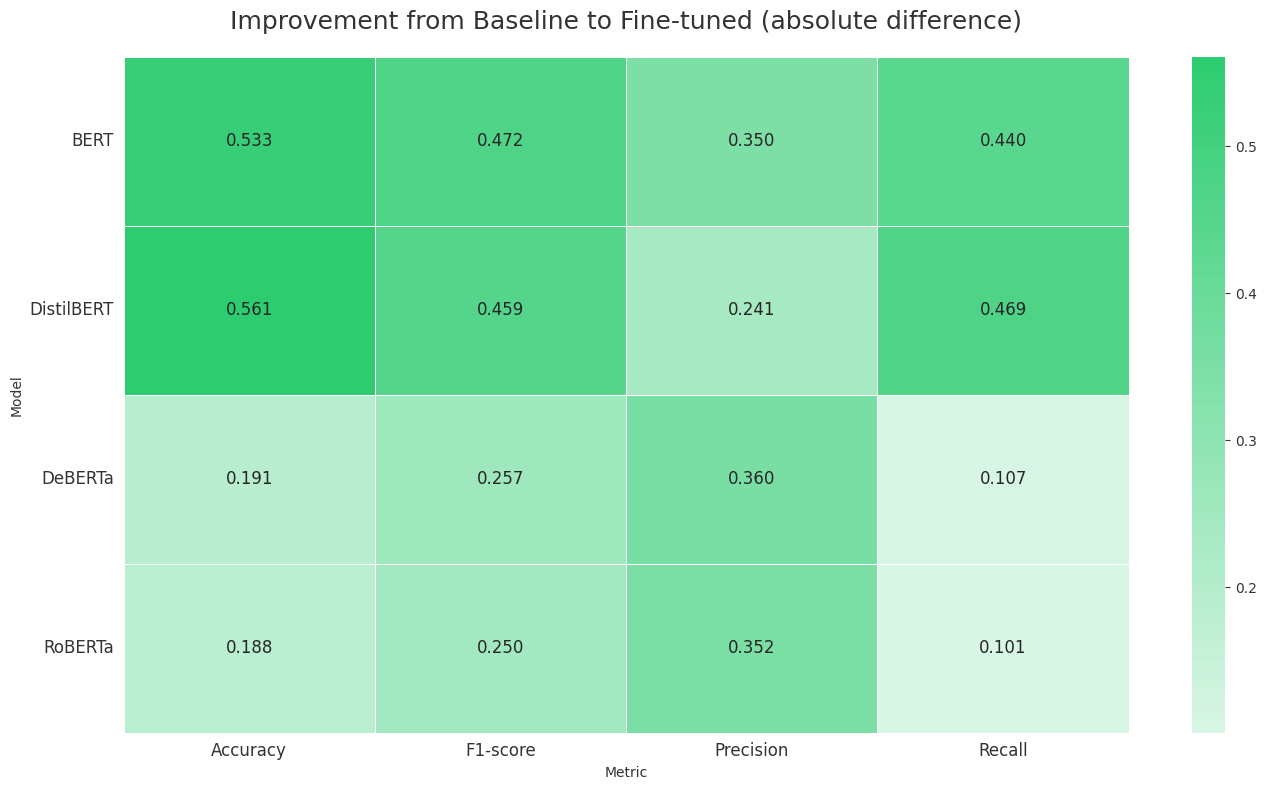

In [ ]:
plt.figure(figsize=(14, 8))
heatmap_df = df.pivot_table(
    index='Model',
    columns='Metric',
    values='Improvement'
)

heatmap_df['Mean_Improvement'] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values('Mean_Improvement', ascending=False)
heatmap_df = heatmap_df.drop(columns=['Mean_Improvement'])

colors = ['#e74c3c', '#ffffff', '#2ecc71']  # Red, white, green
cmap = LinearSegmentedColormap.from_list('RWG', colors, N=256)

plt.title('Improvement from Baseline to Fine-tuned (absolute difference)', fontsize=18, pad=20)
sns.heatmap(heatmap_df, annot=True, cmap=cmap, fmt='.3f', linewidths=0.5, center=0,
            annot_kws={"size": 12})
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

#  Interactive Model Comparison


In [ ]:
from ipywidgets import interact, widgets

@interact(
    model1=widgets.Dropdown(options=sorted(df['Model'].unique())),
    model2=widgets.Dropdown(options=sorted(df['Model'].unique())),
    metric=widgets.Dropdown(options=["Accuracy", "Precision", "Recall", "F1-score"])
)
def compare_two_models(model1, model2, metric="F1-score"):
    # Filter data for the selected models and metric
    model1_data = df[(df['Model'] == model1) & (df['Metric'] == metric)]
    model2_data = df[(df['Model'] == model2) & (df['Metric'] == metric)]

    # Extract values
    m1_baseline = model1_data['Baseline'].values[0]
    m1_fine_tuned = model1_data['Fine-tuned'].values[0]
    m1_improvement = model1_data['Improvement'].values[0]

    m2_baseline = model2_data['Baseline'].values[0]
    m2_fine_tuned = model2_data['Fine-tuned'].values[0]
    m2_improvement = model2_data['Improvement'].values[0]

    # Create comparison plot
    fig, ax = plt.subplots(figsize=(12, 6))

    # Define positions
    x = [0, 1, 3, 4]
    width = 0.4

    # Create bars
    ax.bar([x[0]], [m1_baseline], width, label=f'{model1} Baseline', color='#3498db')
    ax.bar([x[1]], [m1_fine_tuned], width, label=f'{model1} Fine-tuned', color='#2ecc71')
    ax.bar([x[2]], [m2_baseline], width, label=f'{model2} Baseline', color='#9b59b6')
    ax.bar([x[3]], [m2_fine_tuned], width, label=f'{model2} Fine-tuned', color='#f1c40f')

    # Add value labels
    for i, val in enumerate([m1_baseline, m1_fine_tuned, m2_baseline, m2_fine_tuned]):
        ax.text(x[i], val + 0.01, f'{val:.4f}', ha='center')

    # Add improvement labels
    ax.annotate(f'+{m1_improvement:.4f}', xy=(0.5, max(m1_baseline, m1_fine_tuned) + 0.03),
                ha='center', bbox=dict(boxstyle='round,pad=0.3', fc='#f39c12', alpha=0.7))

    ax.annotate(f'+{m2_improvement:.4f}', xy=(3.5, max(m2_baseline, m2_fine_tuned) + 0.03),
                ha='center', bbox=dict(boxstyle='round,pad=0.3', fc='#f39c12', alpha=0.7))

    # Customize plot
    ax.set_title(f'Comparison of {model1} vs {model2} ({metric})', fontsize=16)
    ax.set_ylabel(f'{metric} Score', fontsize=14)
    ax.set_xticks([0.5, 3.5])
    ax.set_xticklabels([model1, model2], fontsize=12)
    ax.set_ylim(0, max(m1_baseline, m1_fine_tuned, m2_baseline, m2_fine_tuned) * 1.2)
    ax.legend()

    plt.tight_layout()
    plt.show()




interactive(children=(Dropdown(description='model1', options=('BERT', 'DeBERTa', 'DistilBERT', 'RoBERTa'), val…

In [ ]:
output_dir = "deberta-finetuned"

deberta_model.save_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")
tokenizer.save_pretrained(output_dir)

('deberta-finetuned/tokenizer_config.json',
 'deberta-finetuned/special_tokens_map.json',
 'deberta-finetuned/vocab.json',
 'deberta-finetuned/merges.txt',
 'deberta-finetuned/added_tokens.json',
 'deberta-finetuned/tokenizer.json')